# Chapter 7 — Frequentist Linear Regression

This notebook accompanies **Chapter 7** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

We have a set of measurements on 248 men — body fat percentage plus thirteen body-measurement predictors (abdomen circumference, BMI, chest, hip, etc.).  Can we predict body fat from the easier-to-measure quantities?

The **linear regression** model says the response $y$ is a linear function of a predictor $x$ plus random noise:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim N(0,\sigma^2).$$

The **maximum-likelihood estimates** (MLEs) of $\beta_0$ and $\beta_1$ have a lovely closed form — no numerical optimisation needed.  We'll derive them from scratch, measure fit with $R^2$, and then discover a cautionary tale: adding more predictors is not always better.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## The data

The dataset records body fat percentage (`BodyFat`) and thirteen body measurements for 248 men.

> **Book link — §7.1.**  Body fat is expensive to measure directly (it requires underwater weighing).  The goal is to find a cheap predictor — something you can measure with a tape measure — that gives a good estimate.

In [2]:
df = pd.read_csv('../DATA/bodyFatClean.csv')
print(df.shape)
df.head()

(248, 15)


,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,BMI
0,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,23.63
1,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,23.33
2,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,24.67
3,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,24.88
4,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,25.52


Let's start with a correlation heatmap — a quick visual summary of which predictors are most closely related to body fat, and which predictors are closely related to *each other*.

> **Book link — Figure 7.2.**  The book shows this heatmap and highlights the strong correlation between Abdomen and BMI ($\hat{\rho} = 0.907$).  That will matter later.

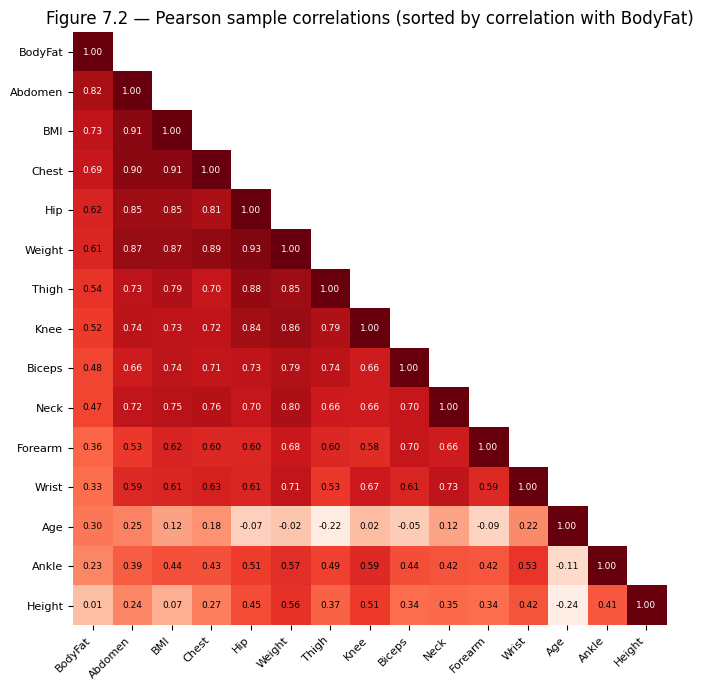

In [3]:
# Sort variables: BodyFat first, then remaining by descending correlation with BodyFat
corr_full = df.corr()
order = ['BodyFat'] + corr_full['BodyFat'].drop('BodyFat').sort_values(ascending=False).index.tolist()
corr = corr_full.loc[order, order]

# Lower triangle only — mask upper triangle with NaN
n = len(order)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)
plot_data = corr.values.copy().astype(float)
plot_data[mask] = np.nan

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(plot_data, vmin=-0.3, vmax=1.0, cmap='Reds',
               aspect='equal', interpolation='none')

# Annotate each visible cell
for i in range(n):
    for j in range(i + 1):
        val = corr.values[i, j]
        color = 'white' if val > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=color)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(order, fontsize=8)
ax.set_title('Figure 7.2 — Pearson sample correlations (sorted by correlation with BodyFat)')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

Abdomen has the strongest correlation with body fat ($\hat{\rho} \approx 0.81$).  Let's use it as our first predictor.

---
## Simple linear regression from scratch

For a single predictor $x$, the MLE of the slope and intercept has a clean closed form:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}.$$

The numerator is the sample covariance of $x$ and $y$; the denominator is the sample variance of $x$.  So $\hat{\beta}_1 = \hat{\sigma}_{xy} / \hat{\sigma}_x^2$.

> **Book link — §7.5.**  These are the MLEs under the Gaussian noise model.  They are also the **least-squares** estimates — the values of $\beta_0, \beta_1$ that minimise $\sum_i (y_i - \beta_0 - \beta_1 x_i)^2$.  The two derivations give the same answer.

In [4]:
def simple_linear_regression(x, y):
    """Closed-form MLE for y = b0 + b1*x + noise."""
    x_bar, y_bar = x.mean(), y.mean()
    b1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
    b0 = y_bar - b1 * x_bar
    return b0, b1

x = df['Abdomen'].values
y = df['BodyFat'].values

b0, b1 = simple_linear_regression(x, y)
print(f"Intercept β̂₀ = {b0:.3f}")
print(f"Slope     β̂₁ = {b1:.3f}")
print()
print(f"Interpretation: each extra cm of abdomen circumference")
print(f"is associated with {b1:.2f} percentage points of body fat.")

Intercept β̂₀ = -42.705
Slope     β̂₁ = 0.669

Interpretation: each extra cm of abdomen circumference
is associated with 0.67 percentage points of body fat.


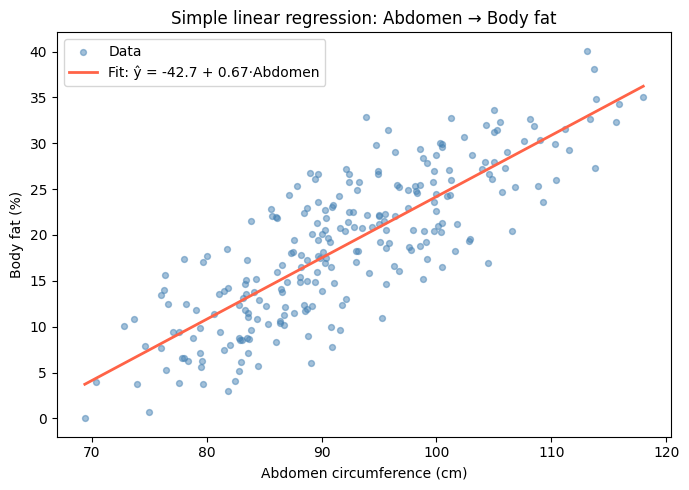

In [5]:
x_line = np.linspace(x.min(), x.max(), 200)
y_line = b0 + b1 * x_line

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, s=18, alpha=0.5, color='steelblue', label='Data')
ax.plot(x_line, y_line, 'tomato', linewidth=2, label=f'Fit: ŷ = {b0:.1f} + {b1:.2f}·Abdomen')
ax.set_xlabel('Abdomen circumference (cm)')
ax.set_ylabel('Body fat (%)')
ax.set_title('Simple linear regression: Abdomen → Body fat')
ax.legend()
plt.tight_layout()
plt.show()

---
## How good is the fit? $R^2$

The **coefficient of determination** $R^2$ measures what fraction of the total variability in $y$ the model explains:

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}, \qquad \text{RSS} = \sum_i (y_i - \hat{y}_i)^2, \quad \text{TSS} = \sum_i (y_i - \bar{y})^2.$$

$R^2 = 1$ means a perfect fit; $R^2 = 0$ means the model does no better than predicting the mean every time.  For simple linear regression, $R^2 = \hat{\rho}^2$ — the square of the sample correlation.

> **Book link — §7.6.**

In [6]:
def r_squared(y, y_hat):
    rss = np.sum((y - y_hat) ** 2)
    tss = np.sum((y - y.mean()) ** 2)
    return 1 - rss / tss

def rmse(y, y_hat):
    return np.sqrt(np.mean((y - y_hat) ** 2))

y_hat = b0 + b1 * x
print(f"R²   = {r_squared(y, y_hat):.3f}")
print(f"RMSE = {rmse(y, y_hat):.3f} percentage points")
print()
print(f"Check: ρ̂² = {np.corrcoef(x, y)[0,1]**2:.3f}  (should equal R²)")

R²   = 0.665
RMSE = 4.659 percentage points

Check: ρ̂² = 0.665  (should equal R²)


Abdomen alone explains 63% of the variance in body fat.  Not bad for a tape measure!

Now let's look at the **residuals** — the errors $e_i = y_i - \hat{y}_i$.  If the model is correct they should look like random noise with no structure.

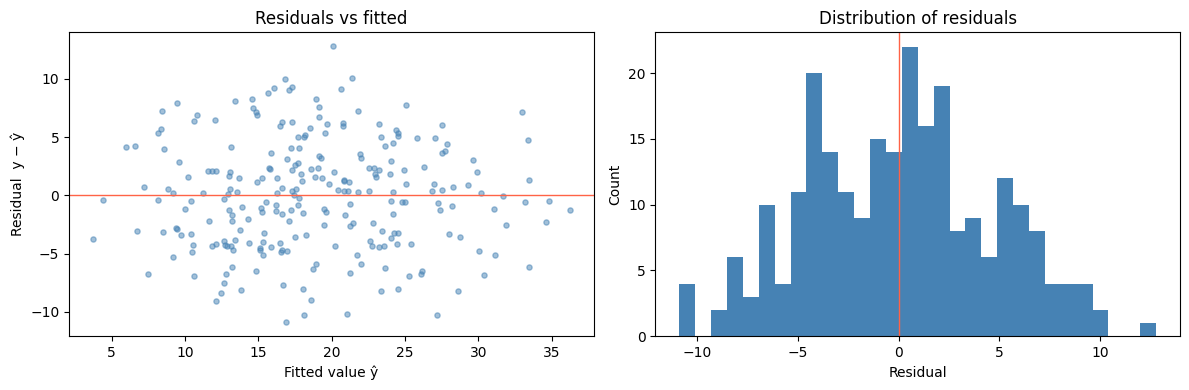

In [7]:
residuals = y - y_hat

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_hat, residuals, s=14, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='tomato', linewidth=1)
axes[0].set_xlabel('Fitted value ŷ')
axes[0].set_ylabel('Residual  y − ŷ')
axes[0].set_title('Residuals vs fitted')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='tomato', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of residuals')

plt.tight_layout()
plt.show()

The residuals look roughly symmetric and there is no strong pattern against the fitted values — the model assumptions seem broadly satisfied.

---
## Collinearity: more predictors ≠ better model

It's tempting to throw every predictor into the model.  But some predictors carry almost the same information.  The heatmap showed that Abdomen and BMI have correlation $\hat{\rho} = 0.907$ — they are nearly redundant.

Let's compare two two-predictor models:

- **Model A**: Abdomen + BMI (highly correlated pair)
- **Model B**: Abdomen + Wrist (much less correlated)

We'll use the normal equations $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$ for the multi-predictor case.

> **Book link — §7.8 Collinearity.**

In [8]:
def fit_ols(X_cols, df):
    """Fit OLS using the normal equations. X_cols: list of column names."""
    y_vec = df['BodyFat'].values
    X = np.column_stack([np.ones(len(df))] + [df[c].values for c in X_cols])
    beta = np.linalg.solve(X.T @ X, X.T @ y_vec)
    y_hat = X @ beta
    r2   = r_squared(y_vec, y_hat)
    err  = rmse(y_vec, y_hat)
    return beta, r2, err

models = {
    'Abdomen only':         ['Abdomen'],
    'Abdomen + BMI':        ['Abdomen', 'BMI'],
    'Abdomen + Wrist':      ['Abdomen', 'Wrist'],
    'Abdomen + Neck':       ['Abdomen', 'Neck'],
    'All 13 predictors':    [c for c in df.columns if c != 'BodyFat'],
}

print(f"{'Model':<25}  {'R²':>6}  {'RMSE':>6}")
print('-' * 42)
for name, cols in models.items():
    _, r2, err = fit_ols(cols, df)
    print(f"{name:<25}  {r2:6.3f}  {err:6.3f}")

Model                          R²    RMSE
------------------------------------------
Abdomen only                0.665   4.659
Abdomen + BMI               0.666   4.656
Abdomen + Wrist             0.702   4.398
Abdomen + Neck              0.692   4.466
All 13 predictors           0.741   4.101


Two striking results:

1. **Adding BMI to Abdomen barely helps** — both carry almost the same signal.  Adding Wrist or Neck (less correlated) gives a bigger improvement per predictor added.

2. **All 13 predictors is not the best model** on training data it looks good ($R^2$ rises), but the RMSE gain over Abdomen alone is tiny.  On new data it would likely be *worse* because we are fitting noise — a problem Chapter 9 addresses with regularisation.

> **Book link — §7.8.**  When two predictors are nearly collinear, the matrix $\mathbf{X}^\top \mathbf{X}$ is nearly singular.  The coefficient estimates become very sensitive to small changes in the data — large standard errors, unstable coefficients.  That's the collinearity problem.

---
## Exercises

### Exercise 1 — Best single predictor

The book claims Abdomen is the best single predictor of body fat.  Loop over all 13 predictors, fit a simple linear regression for each, and record $R^2$.  Plot the results as a horizontal bar chart.  Does Abdomen come top?

In [9]:
# Your answer here
predictors = [c for c in df.columns if c != 'BodyFat']
# ...

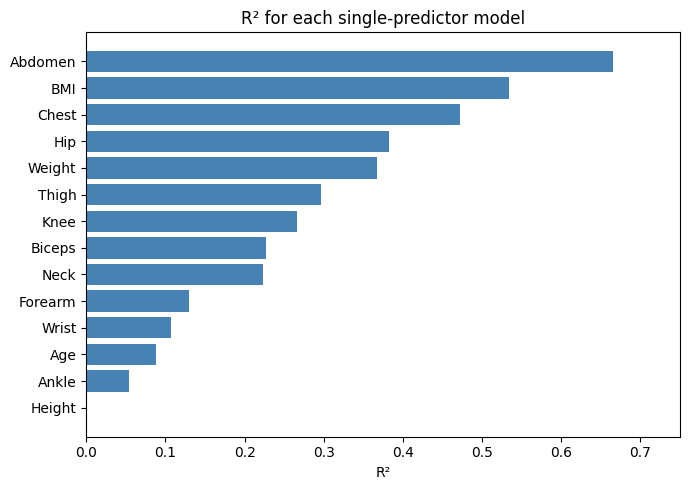

Best predictor: Abdomen   R² = 0.665


In [10]:
# Solution
predictors = [c for c in df.columns if c != 'BodyFat']
y_arr = df['BodyFat'].values

r2_vals = {}
for col in predictors:
    b0c, b1c = simple_linear_regression(df[col].values, y_arr)
    yh = b0c + b1c * df[col].values
    r2_vals[col] = r_squared(y_arr, yh)

r2_series = pd.Series(r2_vals).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(r2_series.index, r2_series.values, color='steelblue')
ax.set_xlabel('R²')
ax.set_title('R² for each single-predictor model')
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

print("Best predictor:", r2_series.idxmax(), f"  R² = {r2_series.max():.3f}")

### Exercise 2 — Residual plot for a weaker predictor

Fit a simple linear regression using `Height` as the predictor.  Plot the residuals against the fitted values.  Compare the residual plot to the one for Abdomen.  What does the much larger spread tell you?

In [11]:
# Your answer here

Height model:   R² = 0.000,  RMSE = 8.050
Abdomen model:  R² = 0.665,  RMSE = 4.659


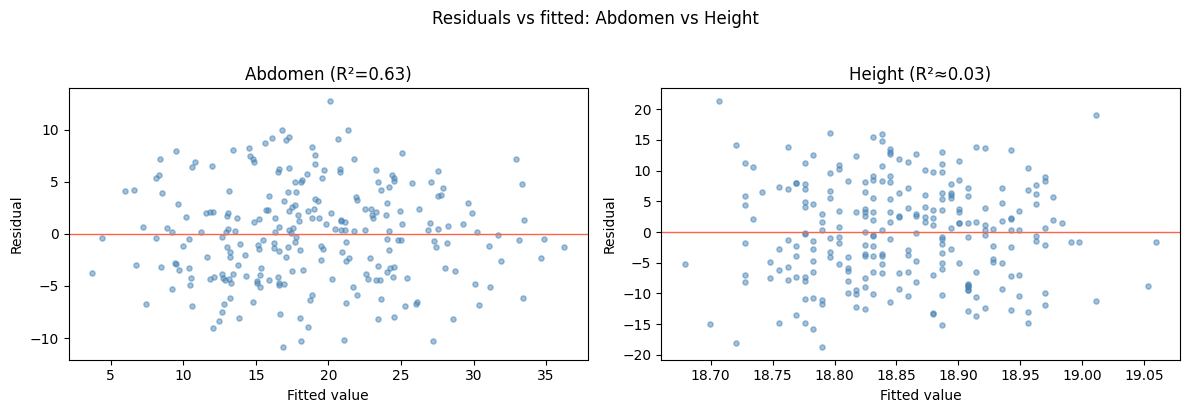

In [12]:
# Solution
x_h = df['Height'].values
b0h, b1h = simple_linear_regression(x_h, y)
yh_h = b0h + b1h * x_h
res_h = y - yh_h

print(f"Height model:   R² = {r_squared(y, yh_h):.3f},  RMSE = {rmse(y, yh_h):.3f}")
print(f"Abdomen model:  R² = {r_squared(y, y_hat):.3f},  RMSE = {rmse(y, y_hat):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, fitted, res, title in zip(
    axes,
    [y_hat, yh_h],
    [residuals, res_h],
    ['Abdomen (R²=0.63)', 'Height (R²≈0.03)']
):
    ax.scatter(fitted, res, s=14, alpha=0.5, color='steelblue')
    ax.axhline(0, color='tomato', linewidth=1)
    ax.set_xlabel('Fitted value')
    ax.set_ylabel('Residual')
    ax.set_title(title)

plt.suptitle('Residuals vs fitted: Abdomen vs Height', y=1.02)
plt.tight_layout()
plt.show()

# Height has almost no linear relationship with body fat — the residuals are nearly
# as spread as the original data.  The model barely improves on guessing the mean.

### Exercise 3 — Collinearity in action

The collinearity problem shows up in the coefficient estimates, not just $R^2$.  Fit three models:

1. Abdomen only
2. BMI only
3. Abdomen + BMI together

Print the fitted slope for Abdomen in models 1 and 3.  Does including BMI change the Abdomen coefficient?  What does this instability tell you about interpreting coefficients in the presence of correlated predictors?

In [13]:
# Your answer here

In [14]:
# Solution
beta_abd,      _, _ = fit_ols(['Abdomen'],        df)
beta_bmi,      _, _ = fit_ols(['BMI'],            df)
beta_abd_bmi,  _, _ = fit_ols(['Abdomen', 'BMI'], df)

print(f"Abdomen only:        β̂_Abdomen = {beta_abd[1]:.4f}")
print(f"BMI only:            β̂_BMI     = {beta_bmi[1]:.4f}")
print(f"Abdomen + BMI:       β̂_Abdomen = {beta_abd_bmi[1]:.4f},  β̂_BMI = {beta_abd_bmi[2]:.4f}")
print()
print(f"Abdomen–BMI correlation: {np.corrcoef(df['Abdomen'], df['BMI'])[0,1]:.3f}")
print()
print("When BMI is added, the Abdomen coefficient changes substantially.")
print("Neither coefficient can be interpreted as a clean 'effect of one variable'.")
print("The model has shared out the credit between two nearly-identical predictors.")

Abdomen only:        β̂_Abdomen = 0.6689
BMI only:            β̂_BMI     = 1.8728
Abdomen + BMI:       β̂_Abdomen = 0.7077,  β̂_BMI = -0.1335

Abdomen–BMI correlation: 0.907

When BMI is added, the Abdomen coefficient changes substantially.
Neither coefficient can be interpreted as a clean 'effect of one variable'.
The model has shared out the credit between two nearly-identical predictors.
